# ARIMAX/SARIMAX 모델링 결과 분석 (2025 홀드아웃)

`src/model_arimax.py` 파이프라인 산출물을 바탕으로 모델 비교·잔차 진단·예측 시각화.

## 실험 설계
- 학습 구간: 2010-01-01 ~ 2024-12-31 (5,479일)
- 평가 구간: 2025-01-01 ~ 2025-12-31 (365일, 홀드아웃)
- 차수 후보 3개: (1,1,1)·(2,1,1)·(1,1,2) × seasonal (1,1,1,7)
- 외생변수 3서브셋: none(SARIMA) / minimal(6개) / phase1(16개)
- → 9개 조합 그리드, AIC 최저 모델 선택
- 평가: 365일 one-shot + rolling 1-step + 베이스라인 3개

## 입력
- `data/processed/arimax/grid_results.csv`
- `data/processed/arimax/forecast.csv`
- `data/processed/arimax/metrics.csv`

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager
import seaborn as sns

warnings.filterwarnings("ignore")

NOTO_PATH = Path("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")
if NOTO_PATH.exists():
    font_manager.fontManager.addfont(str(NOTO_PATH))
KOR_FONT = "Noto Sans CJK JP"
mpl.rcParams["font.family"] = KOR_FONT
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["figure.dpi"] = 110
sns.set_theme(style="whitegrid", rc={"font.family": KOR_FONT})

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARIMAX_DIR = ROOT / "data" / "processed" / "arimax"

grid = pd.read_csv(ARIMAX_DIR / "grid_results.csv", encoding="utf-8-sig")
forecast = pd.read_csv(ARIMAX_DIR / "forecast.csv", encoding="utf-8-sig", parse_dates=["tm"]).set_index("tm")
metrics_df = pd.read_csv(ARIMAX_DIR / "metrics.csv", encoding="utf-8-sig")

print(f"grid: {grid.shape}, forecast: {forecast.shape}, metrics: {metrics_df.shape}")

grid: (9, 9), forecast: (365, 8), metrics: (5, 6)


## 1. 9개 조합 AIC/BIC 비교

In [2]:
grid_disp = grid.copy()
grid_disp["AIC_rank"] = grid_disp["AIC"].rank().astype(int)
grid_disp = grid_disp.sort_values("AIC").reset_index(drop=True)
grid_disp.round(2)

,order,seasonal_order,exog_subset,n_exog,AIC,BIC,loglik,LB_p_lag10,LB_p_lag20,AIC_rank
0,"(1, 1, 2)","(1, 1, 1, 7)",phase1,16,98489.92,98635.23,-49222.96,0.00,0.0,1
1,"(2, 1, 1)","(1, 1, 1, 7)",phase1,16,98536.67,98682.00,-49246.34,0.00,0.0,2
2,"(1, 1, 1)","(1, 1, 1, 7)",phase1,16,98544.91,98683.63,-49251.46,0.00,0.0,3
3,"(1, 1, 2)","(1, 1, 1, 7)",minimal,6,99089.16,99168.43,-49532.58,0.00,0.0,4
4,"(2, 1, 1)","(1, 1, 1, 7)",minimal,6,99116.87,99196.14,-49546.43,0.00,0.0,5
5,"(1, 1, 1)","(1, 1, 1, 7)",minimal,6,99782.60,99855.26,-49880.30,0.00,0.0,6
6,"(1, 1, 2)","(1, 1, 1, 7)",none,0,101782.95,101822.58,-50885.48,0.01,0.0,7
7,"(2, 1, 1)","(1, 1, 1, 7)",none,0,101791.78,101831.41,-50889.89,0.00,0.0,8
8,"(1, 1, 1)","(1, 1, 1, 7)",none,0,101863.85,101896.88,-50926.93,0.00,0.0,9


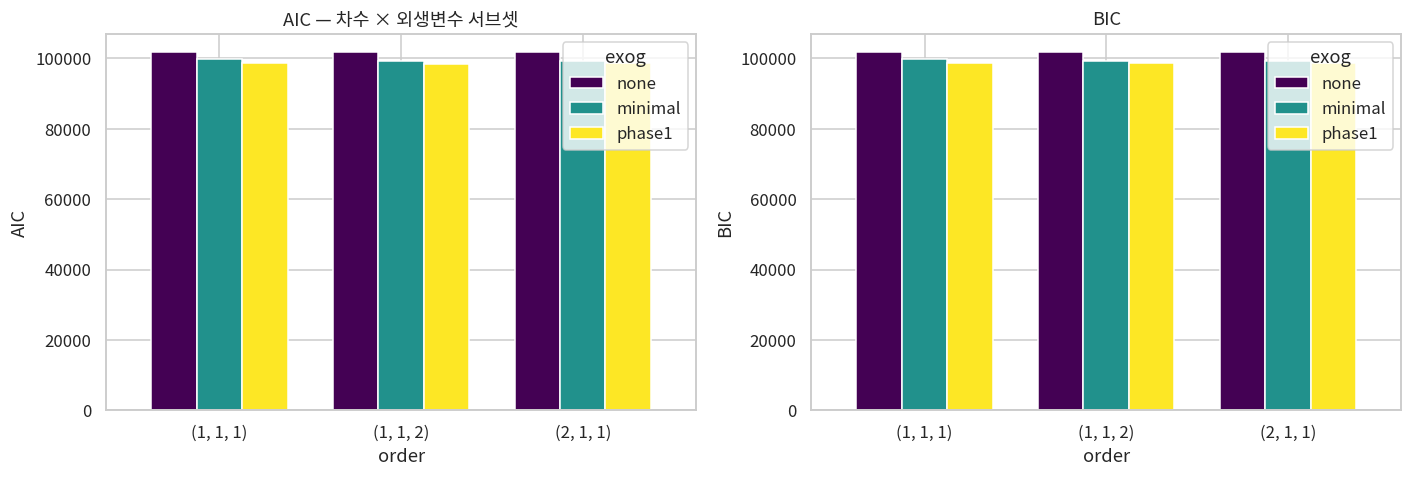

AIC 최저: (1, 1, 2) (1, 1, 1, 7) exog=phase1
  AIC=98489.9, BIC=98635.2
  Ljung-Box p(lag10)=0.0000, p(lag20)=0.0000

외생변수 서브셋별 효과 (같은 차수 기준 AIC 감소):
  (1, 1, 1): none=101864 → minimal=99783 (-2081)  → phase1=98545 (-3319)
  (1, 1, 2): none=101783 → minimal=99089 (-2694)  → phase1=98490 (-3293)
  (2, 1, 1): none=101792 → minimal=99117 (-2675)  → phase1=98537 (-3255)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

piv_aic = grid.pivot(index="order", columns="exog_subset", values="AIC")
piv_bic = grid.pivot(index="order", columns="exog_subset", values="BIC")
piv_aic = piv_aic[["none", "minimal", "phase1"]]
piv_bic = piv_bic[["none", "minimal", "phase1"]]

piv_aic.plot(kind="bar", ax=axes[0], colormap="viridis", width=0.75)
axes[0].set_title("AIC — 차수 × 외생변수 서브셋")
axes[0].set_ylabel("AIC"); axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="exog")

piv_bic.plot(kind="bar", ax=axes[1], colormap="viridis", width=0.75)
axes[1].set_title("BIC")
axes[1].set_ylabel("BIC"); axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="exog")

plt.tight_layout()
plt.show()

best = grid.loc[grid["AIC"].idxmin()]
print(f"AIC 최저: {best['order']} {best['seasonal_order']} exog={best['exog_subset']}")
print(f"  AIC={best['AIC']:.1f}, BIC={best['BIC']:.1f}")
print(f"  Ljung-Box p(lag10)={best['LB_p_lag10']:.4f}, p(lag20)={best['LB_p_lag20']:.4f}")
print("\n외생변수 서브셋별 효과 (같은 차수 기준 AIC 감소):")
for order in piv_aic.index:
    base = piv_aic.loc[order, "none"]
    print(f"  {order}: none={base:.0f} → minimal={piv_aic.loc[order, 'minimal']:.0f} ({piv_aic.loc[order, 'minimal']-base:+.0f})  → phase1={piv_aic.loc[order, 'phase1']:.0f} ({piv_aic.loc[order, 'phase1']-base:+.0f})")

## 2. 2025 예측 vs 실측

### 2.1 전체 365일 시계열 비교

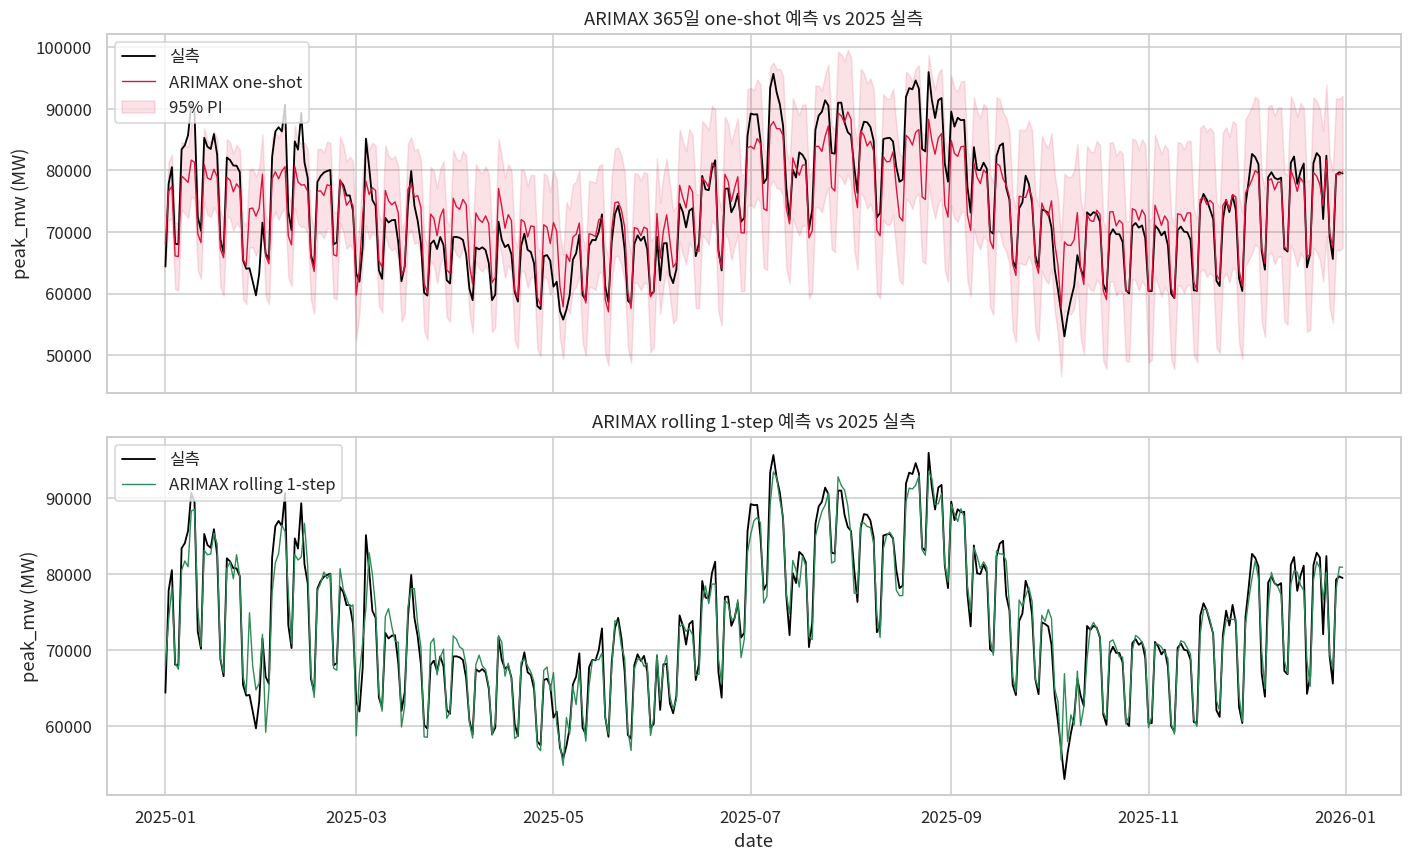

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(forecast.index, forecast["actual"], lw=1.2, color="black", label="실측")
axes[0].plot(forecast.index, forecast["arimax_oneshot"], lw=0.9, color="crimson", label="ARIMAX one-shot")
axes[0].fill_between(forecast.index, forecast["ci_low"], forecast["ci_high"],
                     color="crimson", alpha=0.12, label="95% PI")
axes[0].set_title("ARIMAX 365일 one-shot 예측 vs 2025 실측")
axes[0].set_ylabel("peak_mw (MW)")
axes[0].legend(loc="upper left")

axes[1].plot(forecast.index, forecast["actual"], lw=1.2, color="black", label="실측")
axes[1].plot(forecast.index, forecast["arimax_rolling"], lw=0.9, color="seagreen", label="ARIMAX rolling 1-step")
axes[1].set_title("ARIMAX rolling 1-step 예측 vs 2025 실측")
axes[1].set_ylabel("peak_mw (MW)"); axes[1].set_xlabel("date")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()

### 2.2 평가 지표 표 + 베이스라인 비교

In [5]:
metrics_disp = metrics_df.copy()
metrics_disp["MAE_rel_naive"] = metrics_disp["MAE"] / metrics_disp.loc[metrics_disp["model"] == "Naive (전일)", "MAE"].iloc[0]
metrics_disp.round(3)

,model,MAE,RMSE,MAPE_%,bias_mean,PI95_cov_%,MAE_rel_naive
0,ARIMAX one-shot,3061.685,3963.993,4.156,58.210,95.342,0.710
1,ARIMAX rolling 1-step,1522.556,2184.053,2.092,-3.952,NaN,0.353
2,SARIMA(no exog) one-shot,7336.937,8603.141,10.330,-2532.719,NaN,1.702
3,Naive (전일),4311.110,6241.154,5.945,13.000,NaN,1.000
4,Seasonal Naive (전주 동요일),4602.364,6454.809,6.205,21.548,NaN,1.068


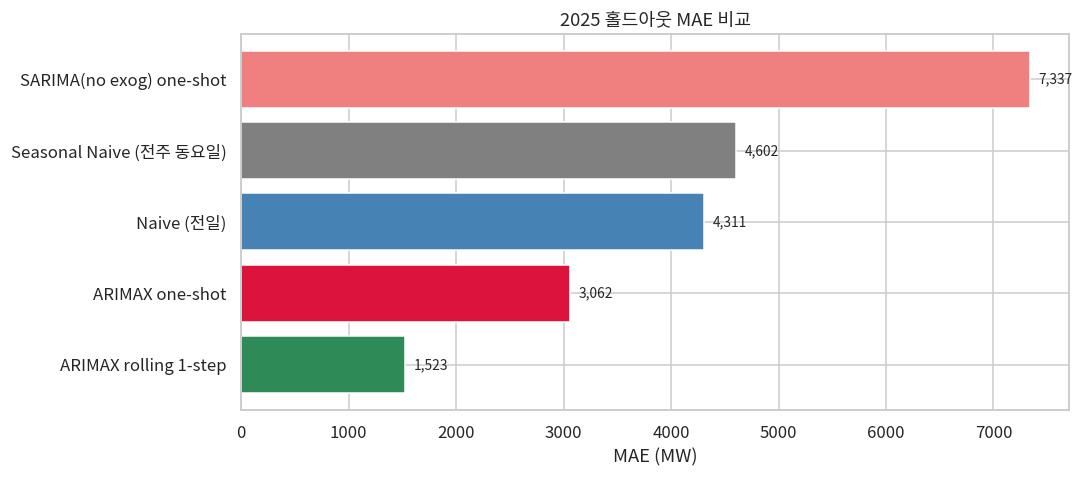

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
order_models = metrics_df.sort_values("MAE", ascending=True)
bars = ax.barh(order_models["model"], order_models["MAE"],
               color=["seagreen", "crimson", "steelblue", "gray", "lightcoral"])
for bar, val in zip(bars, order_models["MAE"]):
    ax.text(val + 80, bar.get_y() + bar.get_height()/2, f"{val:,.0f}",
            va="center", fontsize=9)
ax.set_xlabel("MAE (MW)")
ax.set_title("2025 홀드아웃 MAE 비교")
plt.tight_layout()
plt.show()

### 2.3 오차 분포·시기별 분해

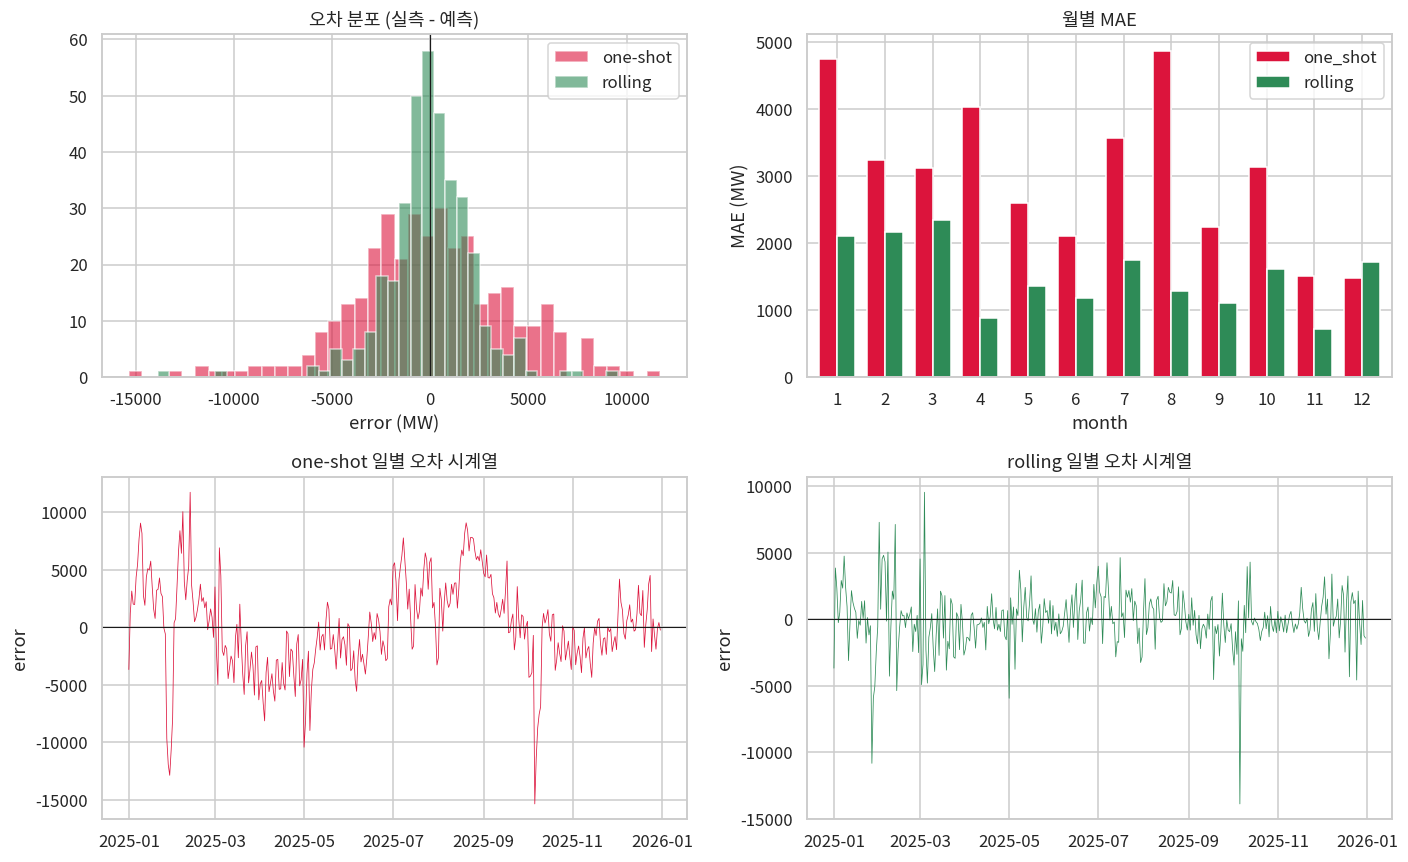

월별 MAE (MW):
       one_shot  rolling
month                   
1        4754.0   2105.0
2        3251.0   2174.0
3        3118.0   2352.0
4        4033.0    885.0
5        2601.0   1360.0
6        2103.0   1179.0
7        3570.0   1756.0
8        4878.0   1281.0
9        2244.0   1109.0
10       3146.0   1617.0
11       1506.0    723.0
12       1480.0   1721.0

one-shot 최악 5일 (절대 오차):
            actual  arimax_oneshot  err_oneshot
tm                                             
2025-10-06   53033         68375.0     -15342.0
2025-01-29   59700         72558.0     -12858.0
2025-01-28   61947         73880.0     -11933.0
2025-02-12   89324         77607.0      11717.0
2025-10-07   56492         67837.0     -11345.0


In [7]:
err = forecast.copy()
err["err_oneshot"] = err["actual"] - err["arimax_oneshot"]
err["err_rolling"] = err["actual"] - err["arimax_rolling"]
err["month"] = err.index.month

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].hist(err["err_oneshot"], bins=40, alpha=0.6, color="crimson", label="one-shot")
axes[0, 0].hist(err["err_rolling"], bins=40, alpha=0.6, color="seagreen", label="rolling")
axes[0, 0].axvline(0, color="k", lw=0.8)
axes[0, 0].set_title("오차 분포 (실측 - 예측)")
axes[0, 0].set_xlabel("error (MW)"); axes[0, 0].legend()

month_mae = err.groupby("month").agg(
    one_shot=("err_oneshot", lambda x: x.abs().mean()),
    rolling=("err_rolling", lambda x: x.abs().mean()),
)
month_mae.plot(kind="bar", ax=axes[0, 1], color=["crimson", "seagreen"], width=0.75)
axes[0, 1].set_title("월별 MAE")
axes[0, 1].set_ylabel("MAE (MW)"); axes[0, 1].tick_params(axis="x", rotation=0)

axes[1, 0].plot(err.index, err["err_oneshot"], lw=0.5, color="crimson")
axes[1, 0].axhline(0, color="k", lw=0.7)
axes[1, 0].set_title("one-shot 일별 오차 시계열")
axes[1, 0].set_ylabel("error")

axes[1, 1].plot(err.index, err["err_rolling"], lw=0.5, color="seagreen")
axes[1, 1].axhline(0, color="k", lw=0.7)
axes[1, 1].set_title("rolling 일별 오차 시계열")
axes[1, 1].set_ylabel("error")

plt.tight_layout()
plt.show()

print("월별 MAE (MW):")
print(month_mae.round(0).to_string())
print()
print(f"one-shot 최악 5일 (절대 오차):")
print(err.reindex(err["err_oneshot"].abs().nlargest(5).index)[["actual", "arimax_oneshot", "err_oneshot"]].round(0).to_string())

## 3. 잔차 진단 (학습 구간)

최적 모델을 재적합 후 잔차 ACF/PACF·정규성 점검. Ljung-Box p값이 작아 잔차에
구조가 남아 있을 가능성이 있음 — 어디서 남는지 확인.

In [8]:
import sys
sys.path.insert(0, str(ROOT / "src"))
from model_arimax import load_data, fit_one, EXOG_SUBSETS

best_row = grid.loc[grid["AIC"].idxmin()]
best_order = eval(best_row["order"])
best_sorder = eval(best_row["seasonal_order"])
best_subset = best_row["exog_subset"]
best_exog = EXOG_SUBSETS[best_subset]

print(f"최적 모델: {best_order} {best_sorder} exog={best_subset}")

data = load_data()
res, info = fit_one(data, best_order, best_sorder, best_exog)
resid = res.resid.iloc[1:]  # 첫 값은 초기화 이슈 제거
print(f"잔차: n={len(resid)}, mean={resid.mean():,.1f}, std={resid.std():,.1f}")

최적 모델: (1, 1, 2) (1, 1, 1, 7) exog=phase1


잔차: n=5478, mean=18.1, std=2,094.4


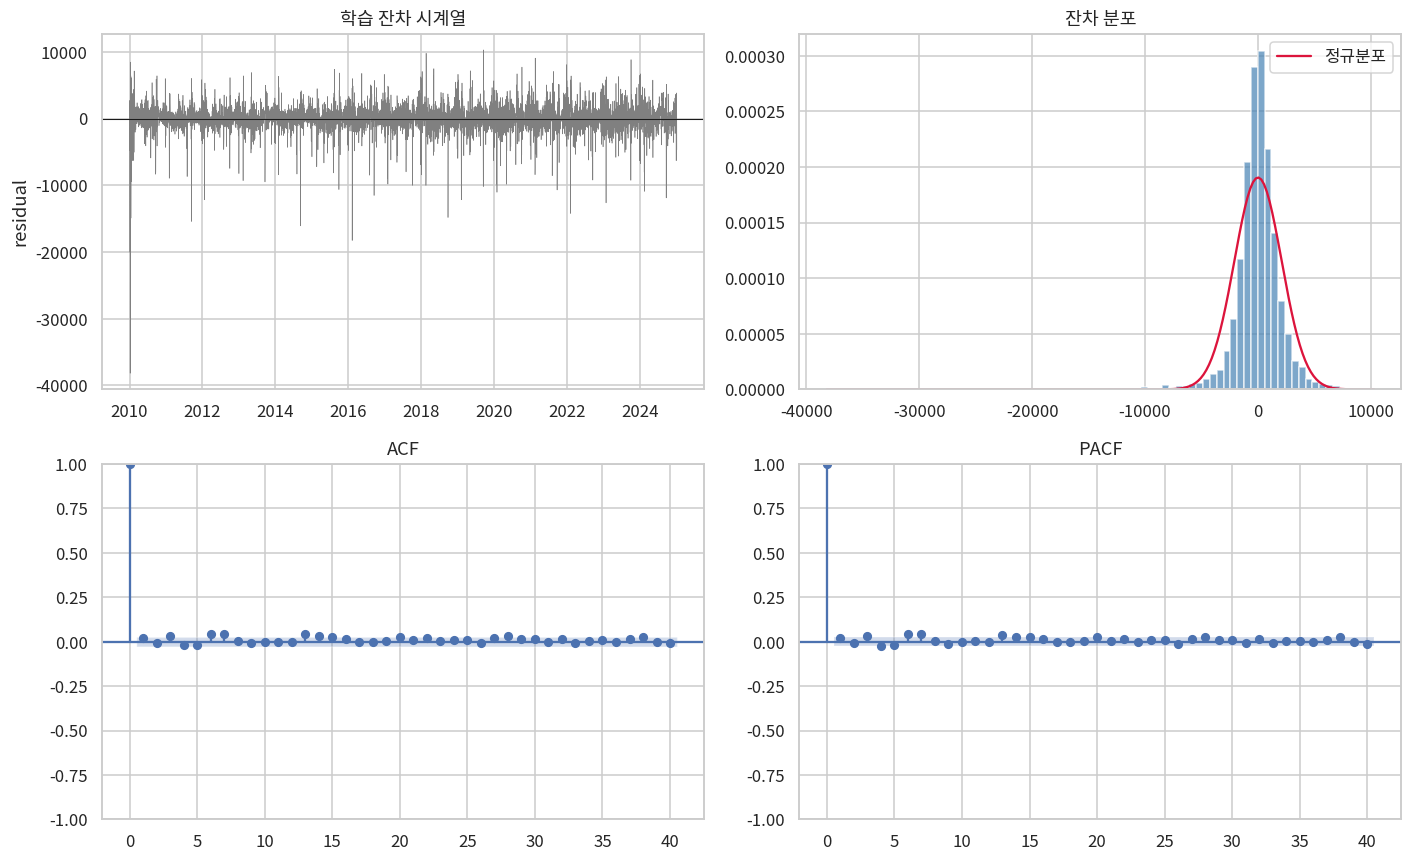

잔차 정규성 (Shapiro test on sample of 2000):
  Shapiro W=0.7935, p=8.652e-45

잔차 skew=-2.295, kurtosis=28.812


In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(resid.index, resid.values, lw=0.4, color="gray")
axes[0, 0].axhline(0, color="k", lw=0.7)
axes[0, 0].set_title("학습 잔차 시계열")
axes[0, 0].set_ylabel("residual")

axes[0, 1].hist(resid, bins=80, density=True, alpha=0.7, color="steelblue")
xs = np.linspace(resid.min(), resid.max(), 200)
axes[0, 1].plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std()), color="crimson", lw=1.5, label="정규분포")
axes[0, 1].set_title("잔차 분포")
axes[0, 1].legend()

plot_acf(resid, lags=40, ax=axes[1, 0], title="ACF")
plot_pacf(resid, lags=40, ax=axes[1, 1], method="ywm", title="PACF")

plt.tight_layout()
plt.show()

print(f"잔차 정규성 (Shapiro test on sample of 2000):")
sample = resid.sample(min(2000, len(resid)), random_state=1)
sw_stat, sw_p = stats.shapiro(sample)
print(f"  Shapiro W={sw_stat:.4f}, p={sw_p:.4g}")
print(f"\n잔차 skew={stats.skew(resid):.3f}, kurtosis={stats.kurtosis(resid):.3f}")

## 4. 외생변수 계수 — 어느 변수가 실제로 효과를 냈나

In [10]:
params = res.params
pvals = res.pvalues
exog_idx = [n for n in params.index if n in best_exog]

coef_df = pd.DataFrame({
    "변수": exog_idx,
    "표준화 계수 (MW/σ)": params.loc[exog_idx].values,
    "p-value": pvals.loc[exog_idx].values,
}).sort_values("표준화 계수 (MW/σ)", key=abs, ascending=False).reset_index(drop=True)

coef_df["유의(α=0.05)"] = (coef_df["p-value"] < 0.05).map({True: "✓", False: ""})
coef_df.round(3)

,변수,표준화 계수 (MW/σ),p-value,유의(α=0.05)
0,cdd_18,3452.650,0.000,✓
1,hdd_18,2662.940,0.000,✓
2,cdd_18_ma7,1994.152,0.000,✓
3,hdd_18_ma7,1828.720,0.000,✓
4,is_holiday,-1268.383,0.000,✓
5,ip_total,-1115.627,0.000,✓
6,pop_total,1021.647,0.053,
7,hm_avg,301.051,0.000,✓
8,ss_day,-290.904,0.000,✓
9,heat_feels_th_2day_adv,111.849,0.001,✓


## 5. 요약 — 모델링 결과

자세한 정리는 `docs/research_log/2026-05-26_*ARIMAX*.md` 참조.

## 6. v3 단계별 개선 (log → OR더미 → 비선형 기온)

`src/model_arimax_v3.py` 산출물 기반. v2 대비 단계별 효과를 분리해서 측정.

In [11]:
v3_results = pd.read_csv(ARIMAX_DIR / "v3_results.csv", encoding="utf-8-sig")
v3_results.round(3)

,model,log_target,n_exog,AIC,BIC,MAE_2025,RMSE_2025,MAPE_2025_%,bias_2025,PI95_cov_%,resid_skew,resid_kurt,LB_p_lag10,LB_p_lag20
0,v2 (baseline),False,14,99214.560,99346.668,2969.096,3867.654,4.035,16.433,97.534,-1.356,9.625,0.04,0.001
1,v3a log,True,14,-23736.233,-23604.126,2735.542,3604.921,3.703,284.824,95.068,-1.692,13.414,0.00,0.000
2,v3b log+OR더미,True,12,-23735.697,-23616.800,2739.208,3611.324,3.706,304.286,95.068,-1.693,13.399,0.00,0.000
3,v3c log+OR+nonlinear,True,14,-23830.960,-23698.853,2667.510,3485.939,3.630,236.079,95.342,-1.755,13.900,0.00,0.000


In [12]:
v3c = pd.read_csv(ARIMAX_DIR / "v3c_forecast.csv", encoding="utf-8-sig", parse_dates=["tm"]).set_index("tm")
v2 = forecast  # 위에서 로드한 v1·v2 공통

v3c["err_oneshot"] = v3c["actual"] - v3c["pred"]
v3c["err_rolling"] = v3c["actual"] - v3c["rolling"]
v3c["m"] = v3c.index.month

v2_cmp = v2.copy()
v2_cmp["err"] = v2_cmp["actual"] - v2_cmp["arimax_oneshot"]
v2_cmp["err_roll"] = v2_cmp["actual"] - v2_cmp["arimax_rolling"]
v2_cmp["m"] = v2_cmp.index.month

monthly = pd.DataFrame({
    "v2_oneshot": v2_cmp.groupby("m")["err"].apply(lambda x: x.abs().mean()),
    "v3c_oneshot": v3c.groupby("m")["err_oneshot"].apply(lambda x: x.abs().mean()),
    "v2_rolling": v2_cmp.groupby("m")["err_roll"].apply(lambda x: x.abs().mean()),
    "v3c_rolling": v3c.groupby("m")["err_rolling"].apply(lambda x: x.abs().mean()),
})
monthly["Δ_oneshot"] = monthly["v3c_oneshot"] - monthly["v2_oneshot"]
monthly["Δ_rolling"] = monthly["v3c_rolling"] - monthly["v2_rolling"]
monthly.round(0)

,v2_oneshot,v3c_oneshot,v2_rolling,v3c_rolling,Δ_oneshot,Δ_rolling
m,,,,,,
1,4754.0,3595.0,2105.0,2072.0,-1159.0,-33.0
2,3251.0,2127.0,2174.0,1678.0,-1124.0,-496.0
3,3118.0,2397.0,2352.0,1720.0,-721.0,-632.0
4,4033.0,2787.0,885.0,775.0,-1246.0,-110.0
5,2601.0,1879.0,1360.0,1117.0,-722.0,-243.0
6,2103.0,1387.0,1179.0,973.0,-716.0,-206.0
7,3570.0,3695.0,1756.0,1599.0,125.0,-157.0
8,4878.0,4885.0,1281.0,1412.0,8.0,132.0
9,2244.0,3912.0,1109.0,955.0,1668.0,-154.0


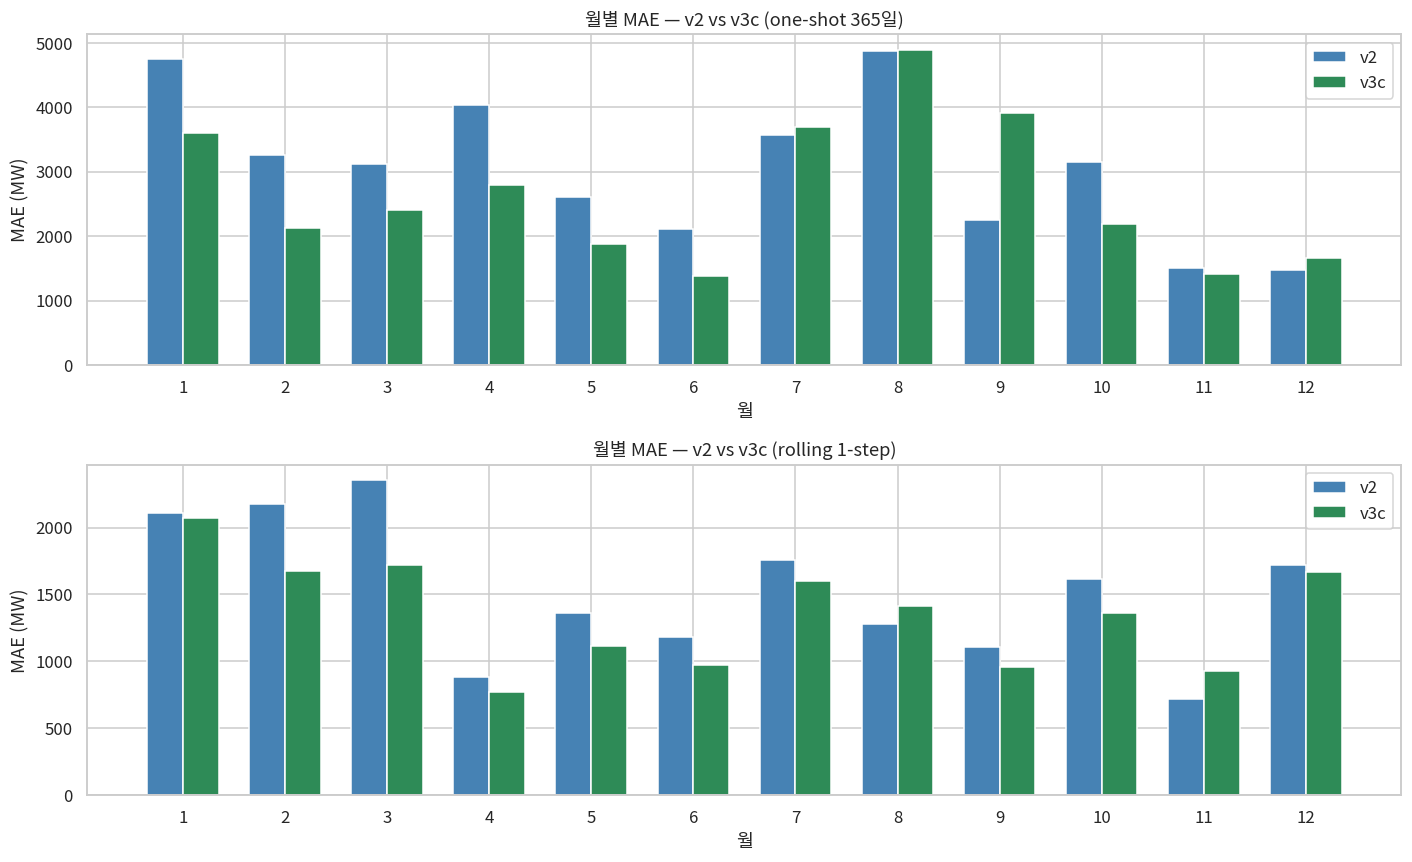

전체 MAE — one-shot: v2=3,062 → v3c=2,668 (-394)
전체 MAE — rolling:  v2=1,523 → v3c=1,357 (-165)


In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

x = np.arange(12)
w = 0.35
axes[0].bar(x - w/2, monthly["v2_oneshot"], w, label="v2", color="steelblue")
axes[0].bar(x + w/2, monthly["v3c_oneshot"], w, label="v3c", color="seagreen")
axes[0].set_xticks(x); axes[0].set_xticklabels(range(1, 13))
axes[0].set_xlabel("월"); axes[0].set_ylabel("MAE (MW)")
axes[0].set_title("월별 MAE — v2 vs v3c (one-shot 365일)")
axes[0].legend()

axes[1].bar(x - w/2, monthly["v2_rolling"], w, label="v2", color="steelblue")
axes[1].bar(x + w/2, monthly["v3c_rolling"], w, label="v3c", color="seagreen")
axes[1].set_xticks(x); axes[1].set_xticklabels(range(1, 13))
axes[1].set_xlabel("월"); axes[1].set_ylabel("MAE (MW)")
axes[1].set_title("월별 MAE — v2 vs v3c (rolling 1-step)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"전체 MAE — one-shot: v2={v2_cmp['err'].abs().mean():,.0f} → v3c={v3c['err_oneshot'].abs().mean():,.0f} ({v3c['err_oneshot'].abs().mean()-v2_cmp['err'].abs().mean():+,.0f})")
print(f"전체 MAE — rolling:  v2={v2_cmp['err_roll'].abs().mean():,.0f} → v3c={v3c['err_rolling'].abs().mean():,.0f} ({v3c['err_rolling'].abs().mean()-v2_cmp['err_roll'].abs().mean():+,.0f})")